In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
nav = pd.read_csv("../1.data/processed/nav_history_cleaned.csv")

nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [3]:
print("Shape:", nav.shape)
print("Funds:", nav['amfi_code'].nunique())
print(nav['daily_return'].describe())

Shape: (46000, 4)
Funds: 40
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [4]:
var_results = []

for fund in nav['amfi_code'].unique():
    r = nav[nav['amfi_code'] == fund]['daily_return'].dropna()

    var_95 = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()

    var_results.append([fund, var_95, cvar_95])

var_df = pd.DataFrame(var_results, columns=[
    "amfi_code", "VaR_95", "CVaR_95"
])

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
var_df.to_csv("../5.reports/var_cvar_report.csv", index=False)

print("VaR CVaR report saved")

VaR CVaR report saved


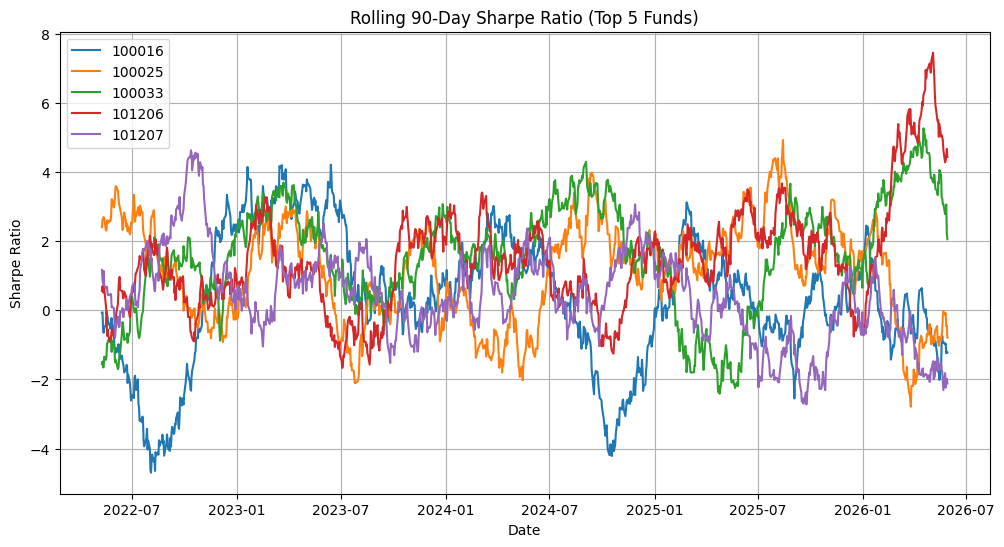

In [6]:
import numpy as np
import matplotlib.pyplot as plt

top5 = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for f in top5:
    temp = nav[nav['amfi_code'] == f].copy()
    r = temp['daily_return']

    rolling_sharpe = (
        r.rolling(90).mean() / r.rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(temp['date'], rolling_sharpe, label=str(f))

plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds)")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid()
plt.show()

In [7]:
plt.savefig("../5.reports/rolling_sharpe_chart.png", bbox_inches='tight')
print("Rolling Sharpe chart saved")

Rolling Sharpe chart saved


<Figure size 640x480 with 0 Axes>

In [8]:
txn = pd.read_csv("../1.data/raw/08_investor_transactions.csv")
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])

txn['cohort_year'] = txn.groupby('investor_id')['transaction_date'].transform('min').dt.year

cohort_summary = txn.groupby('cohort_year')['amount_inr'].agg(['mean','sum','count'])

cohort_summary

,mean,sum,count
cohort_year,,,
2024,107422.541832,3491125187,32499
2025,109158.577061,30455243,279


In [9]:
txn = txn.sort_values(['investor_id', 'transaction_date'])

txn['gap_days'] = txn.groupby('investor_id')['transaction_date'].diff().dt.days

at_risk = txn[txn['gap_days'] > 35]

print("At-risk investors:", at_risk['investor_id'].nunique())

At-risk investors: 4527


In [10]:
performance = pd.read_csv("../1.data/processed/scheme_performance_cleaned.csv")

def recommend(risk_level):
    df = performance[performance['risk_grade'] == risk_level]
    df = df.sort_values('sharpe_ratio', ascending=False)
    return df[['scheme_name','sharpe_ratio']].head(3)

recommend("High")

,scheme_name,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,0.95
38,DSP Midcap Fund - Regular - Growth,0.90


In [11]:
portfolio = pd.read_csv("../1.data/raw/09_portfolio_holdings.csv")

hhi = portfolio.groupby('amfi_code')['weight_pct'].apply(
    lambda x: (x/100)**2
).groupby(level=0).sum()

hhi.head()

amfi_code
100016    0.139534
100033    0.147592
101206    0.129332
101207    0.200700
102885    0.174709
Name: weight_pct, dtype: float64

### Advanced Analytics Insights

1. Funds with high VaR indicate higher downside risk during market stress.
2. Rolling Sharpe shows stability differences between top-performing funds.
3. Older investor cohorts contribute higher total investment volume.
4. SIP gaps greater than 35 days indicate potential investor churn risk.
5. High HHI funds show concentrated sector exposure and higher risk.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import os

for root, dirs, files in os.walk("../1.data"):
    for file in files:
        print(os.path.join(root, file))

../1.data\processed\nav_history_cleaned.csv
../1.data\processed\scheme_performance_cleaned.csv
../1.data\processed\transactions_cleaned.csv
../1.data\raw\01_fund_master.csv
../1.data\raw\02_nav_history.csv
../1.data\raw\03_aum_by_fund_house.csv
../1.data\raw\04_monthly_sip_inflows.csv
../1.data\raw\05_category_inflows.csv
../1.data\raw\06_industry_folio_count.csv
../1.data\raw\07_scheme_performance.csv
../1.data\raw\08_investor_transactions.csv
../1.data\raw\09_portfolio_holdings.csv
../1.data\raw\10_benchmark_indices.csv
../1.data\raw\hdfc_top100_live_nav.csv


In [8]:
import os
print(os.getcwd())

C:\Users\VASAVI\Desktop\bluestock_mf_capstone\2.notebooks


In [9]:
import os
print(os.listdir(".."))

['.git', '1.data', '2.notebooks', '3.sql', '4.dashboard', '5.reports', 'bluestock_mf.db', 'clean_nav_history.py', 'clean_scheme_performance.py', 'clean_transactions.py', 'create_database.py', 'data_dictionary.md', 'data_ingestion.py', 'live_nav_fetch.py', 'queries.sql', 'requirements.txt', 'schema.sql']


In [10]:
import os
print(os.listdir("../1.data"))

['processed', 'raw']


In [11]:
import os
print(os.listdir("../1.data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'hdfc_top100_live_nav.csv']


In [12]:
import pandas as pd

nav = pd.read_csv("../1.data/raw/02_nav_history.csv")
performance = pd.read_csv("../1.data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../1.data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../1.data/raw/09_portfolio_holdings.csv")

print("NAV:", nav.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)

NAV: (46000, 3)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio: (322, 8)


In [13]:
print(nav.columns)
print()
print(performance.columns)
print()
print(transactions.columns)
print()
print(portfolio.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [14]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [15]:
var_report = []

for fund in nav['amfi_code'].unique():

    returns = nav[nav['amfi_code'] == fund]['daily_return'].dropna()

    if len(returns) > 0:

        var_95 = returns.quantile(0.05)

        cvar_95 = returns[returns <= var_95].mean()

        var_report.append([
            fund,
            var_95,
            cvar_95
        ])

var_cvar_report = pd.DataFrame(
    var_report,
    columns=['amfi_code', 'VaR_95', 'CVaR_95']
)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [16]:
var_cvar_report.to_csv(
    "../5.reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully")

var_cvar_report.csv saved successfully


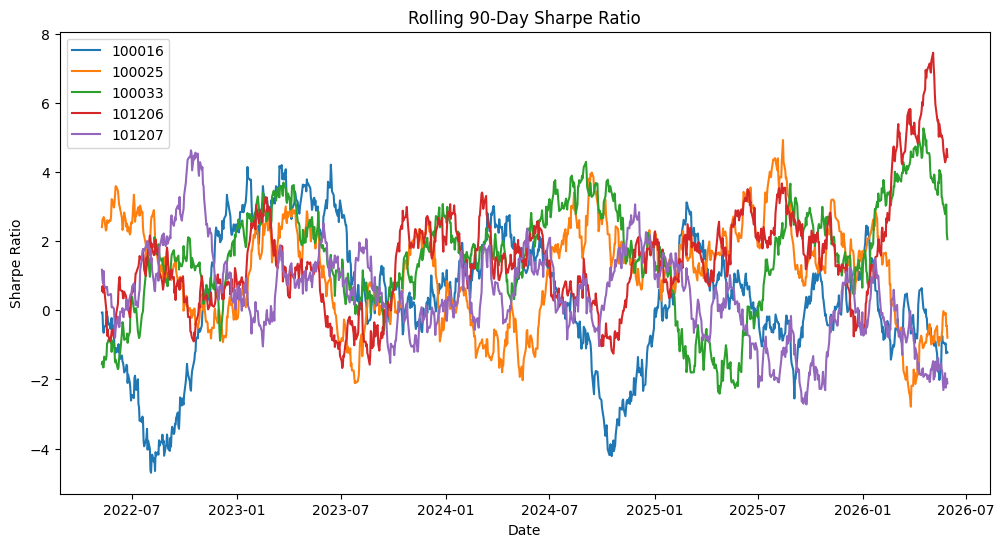

In [17]:
import numpy as np

top5 = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav[nav['amfi_code'] == fund].copy()

    rolling_sharpe = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.show()

rolling_sharpe_chart.png saved successfully


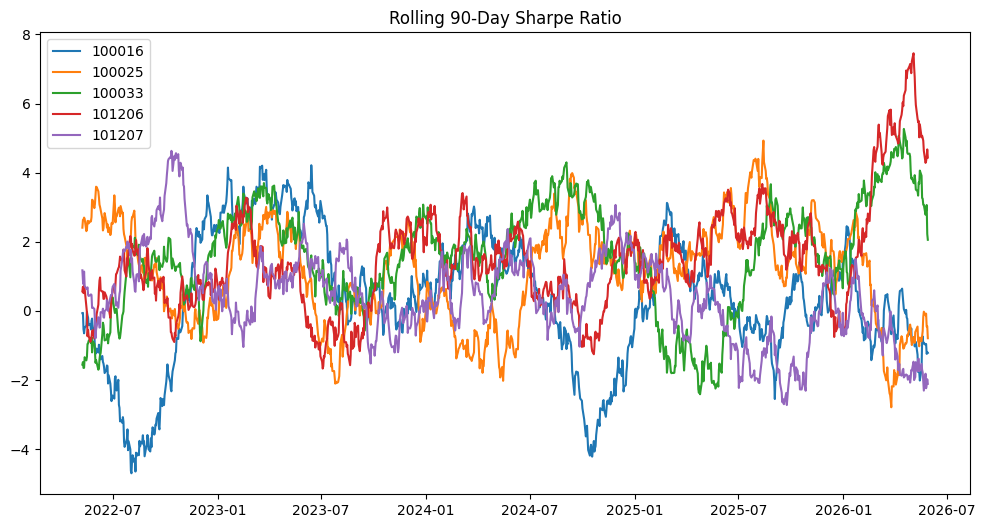

In [18]:
plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav[nav['amfi_code'] == fund].copy()

    rolling_sharpe = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.legend()

plt.savefig(
    "../5.reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

print("rolling_sharpe_chart.png saved successfully")

rolling_sharpe_chart.png saved successfully


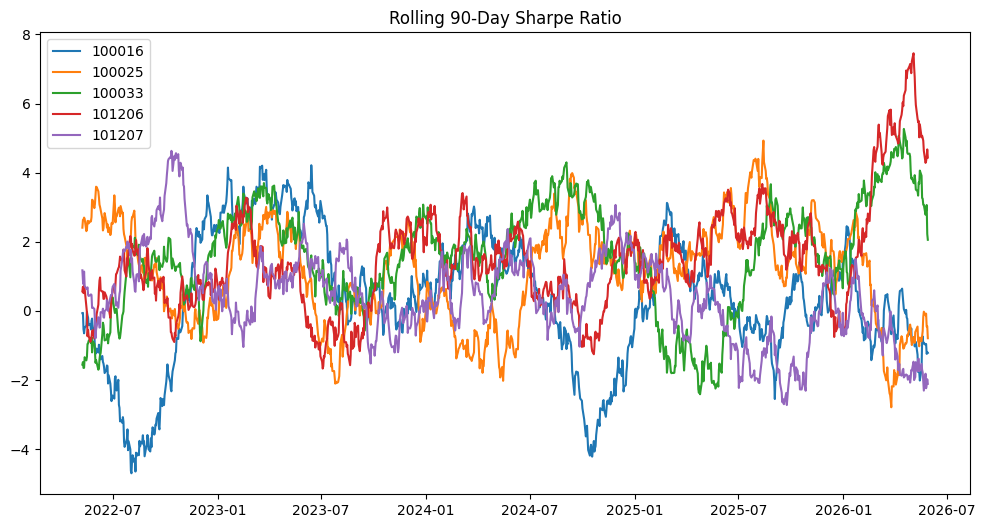

In [19]:
plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav[nav['amfi_code'] == fund].copy()

    rolling_sharpe = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.legend()

plt.savefig(
    "../5.reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

print("rolling_sharpe_chart.png saved successfully")

rolling_sharpe_chart.png saved successfully


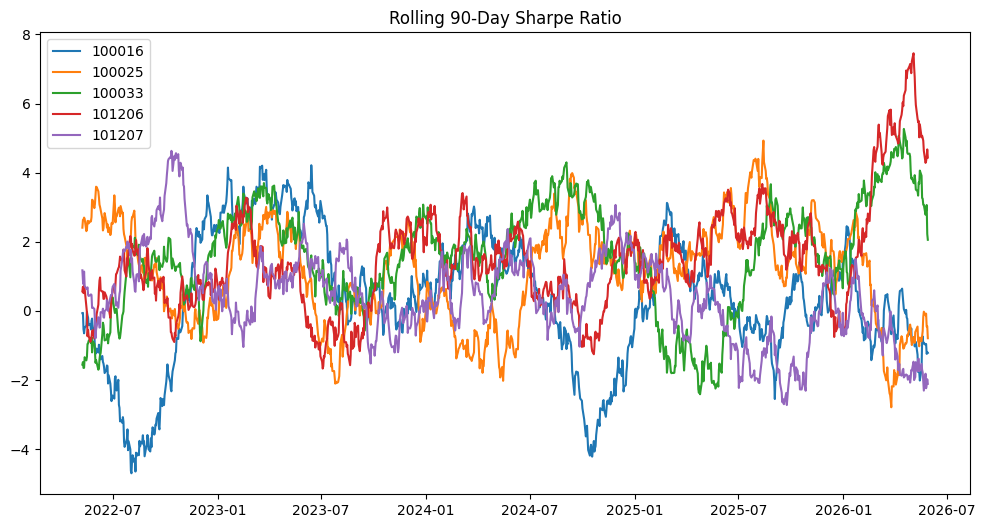

In [20]:
plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav[nav['amfi_code'] == fund].copy()

    rolling_sharpe = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.legend()

plt.savefig(
    "../5.reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

print("rolling_sharpe_chart.png saved successfully")

In [23]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

first_txn = transactions.groupby(
    'investor_id'
)['transaction_date'].min()

cohort = first_txn.dt.year.reset_index()

cohort.columns = [
    'investor_id',
    'cohort_year'
]

transactions = transactions.merge(
    cohort,
    on='investor_id'
)

print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year'],
      dtype='str')


In [24]:
cohort_summary = transactions.groupby(
    'cohort_year'
).agg(
    avg_investment=('amount_inr', 'mean'),
    total_investment=('amount_inr', 'sum'),
    investors=('investor_id', 'nunique')
).reset_index()

cohort_summary

,cohort_year,avg_investment,total_investment,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [25]:
cohort_summary.to_csv(
    "../5.reports/cohort_analysis.csv",
    index=False
)

print("cohort_analysis.csv saved")

cohort_analysis.csv saved


In [26]:
sip = transactions[
    transactions['transaction_type'] == 'SIP'
].copy()

sip = sip.sort_values(
    ['investor_id', 'transaction_date']
)

sip['gap_days'] = sip.groupby(
    'investor_id'
)['transaction_date'].diff().dt.days

sip_summary = sip.groupby(
    'investor_id'
).agg(
    sip_count=('transaction_date', 'count'),
    avg_gap_days=('gap_days', 'mean')
).reset_index()

sip_summary = sip_summary[
    sip_summary['sip_count'] >= 6
]

sip_summary['status'] = np.where(
    sip_summary['avg_gap_days'] > 35,
    'At Risk',
    'Active'
)

sip_summary.head()

,investor_id,sip_count,avg_gap_days,status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk


In [27]:
sip_summary['status'].value_counts()

status
At Risk    1332
Active       30
Name: count, dtype: int64

In [28]:
recommendations = performance.sort_values(
    'sharpe_ratio',
    ascending=False
)[[
    'scheme_name',
    'risk_grade',
    'sharpe_ratio'
]]

recommendations.head(10)

,scheme_name,risk_grade,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68
23,Kotak Liquid Fund - Regular - Growth,Low,6.18
30,ABSL Liquid Fund - Regular - Growth,Low,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,Low,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,Low,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03
15,Nippon India Large Cap Fund - Regular - Growth,Moderate,1.00


In [29]:
for risk in performance['risk_grade'].unique():

    print("\n", risk)

    display(
        performance[
            performance['risk_grade'] == risk
        ].sort_values(
            'sharpe_ratio',
            ascending=False
        )[[
            'scheme_name',
            'sharpe_ratio'
        ]].head(3)
    )


 Moderate


,scheme_name,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03



 Very High


,scheme_name,sharpe_ratio
2,SBI Small Cap Fund - Regular Plan - Growth,0.94
3,SBI Small Cap Fund - Direct Plan - Growth,0.93
29,ABSL Small Cap Fund - Regular - Growth,0.90



 Low


,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14



 High


,scheme_name,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,0.95
38,DSP Midcap Fund - Regular - Growth,0.90



 Moderately High


,scheme_name,sharpe_ratio
13,ICICI Pru Value Discovery Fund - Regular - Growth,0.98
22,Kotak Flexicap Fund - Regular - Growth,0.98
33,UTI Flexi Cap Fund - Regular - Growth,0.96


In [30]:
hhi = portfolio.groupby(
    'amfi_code'
)['weight_pct'].apply(
    lambda x: (x**2).sum()
).reset_index()

hhi.columns = [
    'amfi_code',
    'HHI'
]

hhi.sort_values(
    'HHI',
    ascending=False
).head()

,amfi_code,HHI
11,119092,2064.4767
3,101207,2007.0043
18,119599,1747.5096
4,102885,1747.0902
7,118632,1682.9820


1. Investor cohort 2024 contributed the highest investment amount, exceeding ₹3.49 billion.

2. More than 1300 SIP investors are classified as "At Risk" due to average transaction gaps above 35 days.

3. Rolling Sharpe ratios show significant variation across funds, indicating changing risk-adjusted performance over time.

4. Funds with higher VaR and CVaR values exhibit greater downside risk exposure.

5. HHI analysis indicates some funds are highly concentrated in a few holdings, increasing portfolio concentration risk.